In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA

## The Data

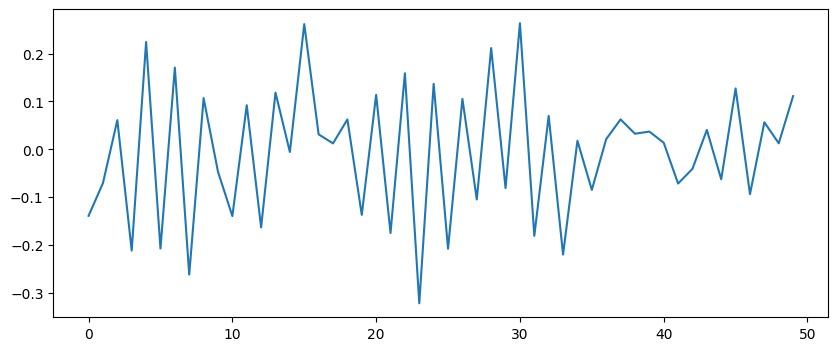

In [20]:
true_phi_1 = -0.2
true_phi_2 = 0.5
true_sigma = 0.1

xvals = [np.random.normal(0, true_sigma), np.random.normal(0, true_sigma)]
for _ in range(50):
    xvals.append(true_phi_1*xvals[-1] + true_phi_2*xvals[-2] + np.random.normal(0, true_sigma))
xvals = np.array(xvals[2:])
plt.figure(figsize=(10,4))
plt.plot(xvals)

## Usual Method : Fit AR Model

In [21]:
model = ARIMA(xvals, order=(2,0,0)).fit(method_kwargs={"maxiter": 200})
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   50
Model:                 ARIMA(2, 0, 0)   Log Likelihood                  47.492
Date:                Sat, 12 Apr 2025   AIC                            -86.984
Time:                        17:24:01   BIC                            -79.336
Sample:                             0   HQIC                           -84.072
                                 - 50                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0064      0.014     -0.457      0.648      -0.034       0.021
ar.L1         -0.3640      0.134     -2.711      0.007      -0.627      -0.101
ar.L2          0.4357      0.129      3.366      0.001       0.182       0.689
sigma2         0.0086      0.002      3.946      0.000       0.004       0.013
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                 0.89
Prob(Q):                              0.73   Prob(JB):                         0.64
Heteroskedasticity (H):               0.34   Skew:                            -0.03
Prob(H) (two-sided):                  0.03   Kurtosis:                         2.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

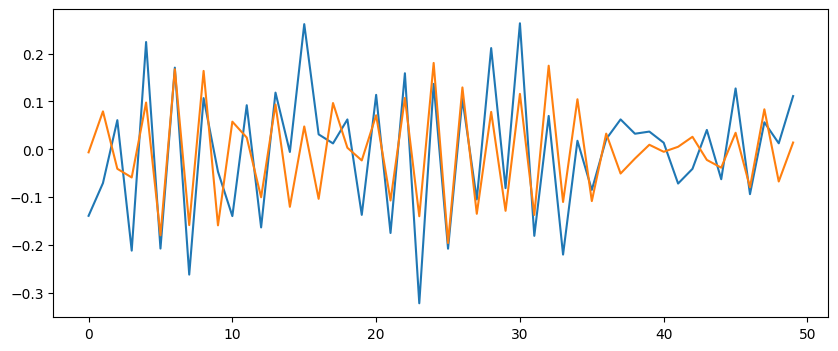

In [22]:
plt.figure(figsize=(10,4))
plt.plot(xvals)
plt.plot(model.fittedvalues)

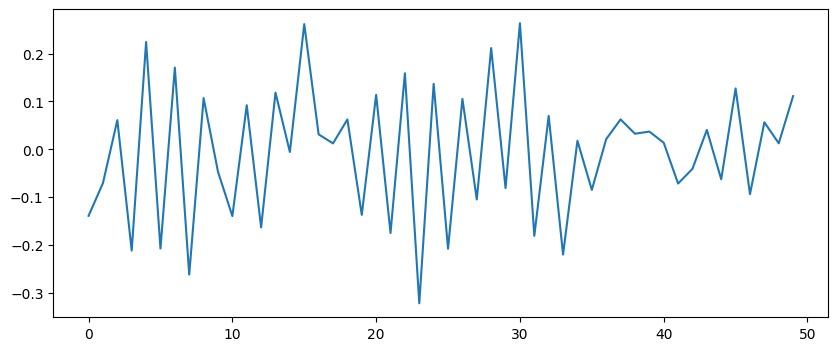

In [23]:
plt.figure(figsize=(10,4))
plt.plot(xvals)

In [24]:
forecast = model.forecast(5)
forecast

array([-0.0409628 ,  0.05744341, -0.04467679,  0.03536997, -0.0382599 ])

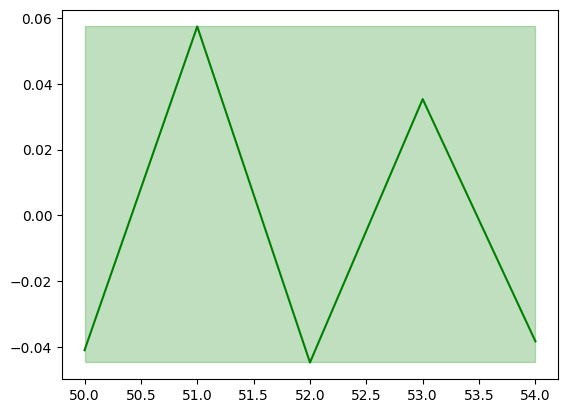

In [30]:
plt.plot(range(len(xvals), len(xvals) + 5), forecast, color='g')
plt.fill_between(range(len(xvals), len(xvals) + 5), forecast.min(),forecast.max(), color='g', alpha=0.25)

## Bayesian Analysis with PyMC3
---
priors:
$$
\phi{1} \sim N(0,20)
$$
$$
\phi{2} \sim N(0,20)
$$
$$
\sigma  \sim \exp(1)
$$
---
likehoold:
$$
x_{t}|\pi{1},\pi{2},\sigma,x_{t-1},x_{x-2}\sim N(\pi{1}+x_{t-1},\pi{2}+x_{t-2},\sigma)
$$
---
posterior:
$$
\pi{1},\pi{2},\sigma|x\sim ?
$$
---

In [ ]:
with pm.Model() as bayes_model:

    phi = pm.Normal("phi", mu=0, sigma=20, shape=2)
    sigma = pm.Exponential("sigma", lam=1)

    likelihood = pm.AR("x", phi, sigma, observed=xvals)

    trace = pm.sample(1000, cores=2)
    
plt.figure(figsize=(7, 7))
pm.traceplot(trace)
plt.tight_layout()

## Parameter Distributions


In [ ]:
phi1_vals = trace.get_values('phi')[:,0]
phi2_vals = trace.get_values('phi')[:,1]
sigma_vals = trace.get_values('sigma')

plt.figure(figsize=(10,4))
sns.distplot(phi1_vals)
plt.axvline(true_phi_1, color='k')
plt.title('phi1 Posterior Distribution\nPosterior Mean: %s'%round(phi1_vals.mean(), 3), fontsize=20)
plt.show()

plt.figure(figsize=(10,4))
sns.distplot(phi2_vals)
plt.axvline(true_phi_2, color='k')
plt.title('phi2 Posterior Distribution\nPosterior Mean: %s'%round(phi2_vals.mean(), 3), fontsize=20)
plt.show()

plt.figure(figsize=(10,4))
sns.distplot(sigma_vals)
plt.axvline(true_sigma, color='k')
plt.title('sigma Posterior Distribution\nPosterior Mean: %s'%round(sigma_vals.mean(), 3), fontsize=20)
plt.show()

## Forecast Next Values


In [ ]:
num_samples = 10000
forecasted_vals = []
num_periods = 5

for _ in range(num_samples):
    curr_vals = list(xvals.copy())
    
    phi1_val = np.random.choice(phi1_vals)
    phi2_val = np.random.choice(phi2_vals)
    sigma_val = np.random.choice(sigma_vals)
    
    for _ in range(num_periods):
        curr_vals.append(curr_vals[-1]*phi1_val + curr_vals[-2]*phi2_val + np.random.normal(0, sigma_val))
    forecasted_vals.append(curr_vals[-num_periods:]) 
forecasted_vals = np.array(forecasted_vals)

In [ ]:
for i in range(num_periods):
    plt.figure(figsize=(10,4))
    vals = forecasted_vals[:,i]
    mu, dev = round(vals.mean(), 3), round(vals.std(), 3)
    sns.distplot(vals)
    p1 = plt.axvline(forecast[0][i], color='k')
    p2 = plt.axvline(vals.mean(), color='b')
    plt.legend((p1,p2), ('MLE', 'Posterior Mean'), fontsize=20)
    plt.title('Forecasted t+%s\nPosterior Mean: %s\nMLE: %s\nSD Bayes: %s\nSD MLE: %s'%((i+1), mu, round(forecast[0][i],3), dev, round(forecast[1][i],3)), fontsize=20)